In [107]:
import pandas as pd
import numpy as np
from pathlib import Path 
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
os.getcwd()

'c:\\Users\\chodu\\Desktop\\midterm2026\\project'

In [109]:
path = os.path.abspath(os.path.join(os.getcwd(), '..'))
path = os.path.join(path, "data", "raw", "apartments.csv")

apartments = pd.read_csv(path)


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\chodu\\Desktop\\midterm2026\\data\\raw\\apartments.csv'

In [ ]:
apartments
apartments.info()
len(apartments)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   price        1363 non-null   int64 
 1   charges      1363 non-null   int64 
 2   surface      1363 non-null   int64 
 3   disposition  1363 non-null   object
 4   address      1363 non-null   object
 5   district     1363 non-null   object
dtypes: int64(3), object(3)
memory usage: 64.0+ KB


1363

In [ ]:
apartments

,price,charges,surface,disposition,address,district
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Praha-Kyje
1,40621,7168,40,UNDEFINED,"Starokošířská, Praha - Košíře",Praha-Košíře
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Praha-Stodůlky
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Praha-Vysočany
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Praha-Košíře
...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Praha-Vinohrady
1359,31987,5645,31,UNDEFINED,"Kmochova, Praha - Smíchov",Praha-Smíchov
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Praha-Holešovice
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Praha-Podolí


In [ ]:
#calculate full cost= price+charges
apartments["full_cost"]=apartments["price"]+apartments["charges"]
apartments


,price,charges,surface,disposition,address,district,full_cost
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Praha-Kyje,19200
1,40621,7168,40,UNDEFINED,"Starokošířská, Praha - Košíře",Praha-Košíře,47789
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Praha-Stodůlky,34000
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Praha-Vysočany,15990
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Praha-Košíře,27500
...,...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Praha-Vinohrady,46949
1359,31987,5645,31,UNDEFINED,"Kmochova, Praha - Smíchov",Praha-Smíchov,37632
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Praha-Holešovice,27000
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Praha-Podolí,22500


In [ ]:
#type of the flat
apartments["disposition"].value_counts()

disposition
DISP_2_KK     400
DISP_1_KK     288
UNDEFINED     274
DISP_2_1      120
DISP_3_KK     106
DISP_3_1       62
DISP_1_1       52
GARSONIERA     23
DISP_4_KK      21
DISP_4_1        9
DISP_5_1        3
OSTATNI         2
DISP_5_KK       1
DISP_7_1        1
DISP_6_1        1
Name: count, dtype: int64

In [ ]:
apartments["disposition"]=apartments["disposition"].replace("UNDEFINED",np.nan)
apartments["disposition"]=apartments["disposition"].replace("OSTATNI",np.nan)
apartments["disposition"].isna().sum()/len(apartments)

np.float64(0.202494497432135)

In [ ]:
apartments["disposition_clean"]=apartments["disposition"].str.replace("DISP_","",regex=False).str.replace("_","+")


In [ ]:
apartments["disposition_clean"]=apartments["disposition_clean"].fillna("unknown")
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Praha-Kyje,19200,1+KK
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Praha-Košíře,47789,unknown
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Praha-Stodůlky,34000,3+KK
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Praha-Vysočany,15990,1+KK
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Praha-Košíře,27500,2+1
...,...,...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Praha-Vinohrady,46949,3+1
1359,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Praha-Smíchov,37632,unknown
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Praha-Holešovice,27000,2+KK
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Praha-Podolí,22500,2+KK


In [ ]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Praha-Kyje,19200,1+KK
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Praha-Košíře,47789,unknown
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Praha-Stodůlky,34000,3+KK
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Praha-Vysočany,15990,1+KK
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Praha-Košíře,27500,2+1
...,...,...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Praha-Vinohrady,46949,3+1
1359,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Praha-Smíchov,37632,unknown
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Praha-Holešovice,27000,2+KK
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Praha-Podolí,22500,2+KK


In [ ]:
# price per m2
apartments["price_per_m2"] = apartments["full_cost"]/apartments["surface"]

In [ ]:
#separate district 
apartments["district"] = apartments["district"].str.replace("Praha-", "", regex=False)

In [ ]:
#drop duplicates
apartments.duplicated().sum()
apartments[apartments.duplicated(keep=False)]
apartments=apartments.drop_duplicates()

count    1349.000000
mean       54.731653
std        43.285873
min         0.000000
25%        35.000000
50%        49.000000
75%        63.000000
max      1080.000000
Name: surface, dtype: float64


<Axes: >

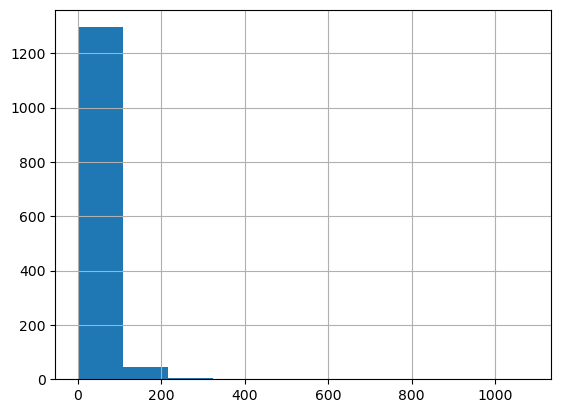

In [ ]:
print(apartments["surface"].describe())
apartments["surface"].hist()

In [ ]:
apartments.sort_values("surface",ascending=False)

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2
395,40200,7094,1080,NaN,"Kutilova, Praha - Modřany",Modřany,47294,unknown,43.790741
105,418747,73896,750,NaN,"Karla Tomáše, Praha - Horní Počernice",Horní Počernice,492643,unknown,656.857333
63,16371,2889,300,NaN,"Lublaňská, Praha - Vinohrady",Vinohrady,19260,unknown,64.200000
92,10739,1895,300,NaN,"Révová, Praha - Strašnice",Strašnice,12634,unknown,42.113333
672,16795,2964,297,NaN,"Lublaňská, Praha - Vinohrady",Vinohrady,19759,unknown,66.528620
...,...,...,...,...,...,...,...,...,...
862,10700,0,10,DISP_5_1,"Moskevská, Praha - Vršovice",Vršovice,10700,5+1,1070.000000
339,7200,2000,10,GARSONIERA,"Davídkova, Praha - Libeň",Libeň,9200,GARSONIERA,920.000000
1006,30802,5436,0,NaN,"Poděbradská, Praha - Vysočany",Vysočany,36238,unknown,inf
104,41702,7359,0,NaN,"náměstí Jiřího z Poděbrad, Praha - Vinohrady",Vinohrady,49061,unknown,inf


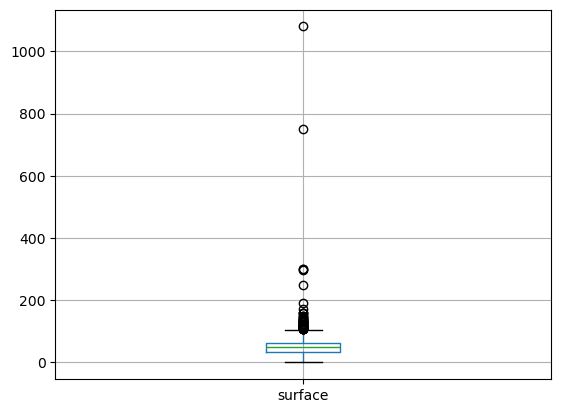

In [ ]:
apartments.boxplot(column="surface")
plt.show()

count    1339.000000
mean       53.088872
std        24.383588
min        12.000000
25%        36.000000
50%        49.000000
75%        63.000000
max       250.000000
Name: surface, dtype: float64

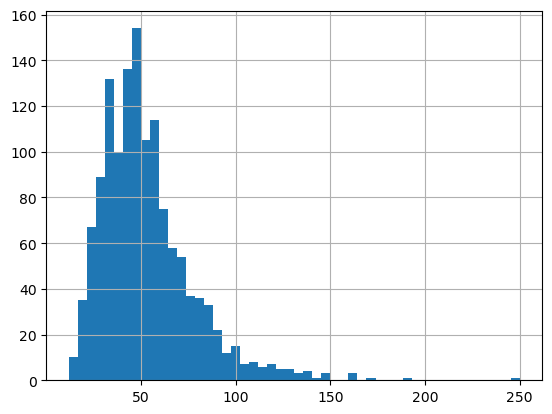

In [ ]:
#hard remove - remove extreme villas 
apartments=apartments[apartments["surface"]>10]
apartments=apartments[apartments["surface"]<=250]
apartments["surface"].hist(bins=50)
apartments["surface"].describe()

count      1339.000000
mean      33556.711725
std       24111.777845
min        7500.000000
25%       22140.000000
50%       27500.000000
75%       34566.500000
max      280814.000000
Name: full_cost, dtype: float64


<Axes: >

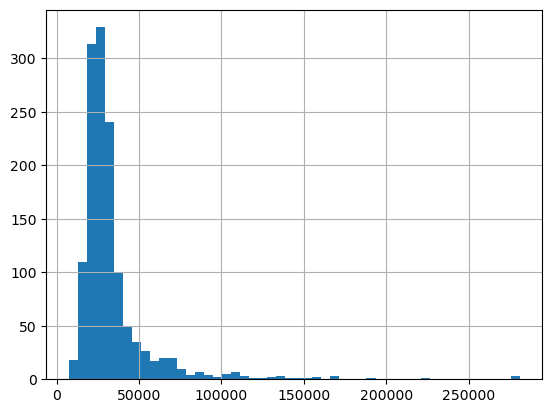

In [ ]:
print(apartments["full_cost"].describe())
apartments["full_cost"].hist(bins=50)

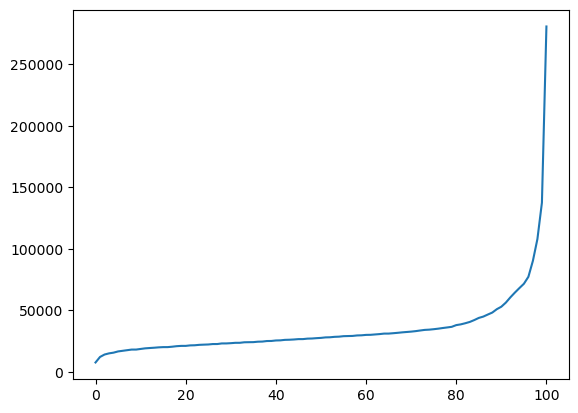

In [ ]:
p=np.percentile(apartments["full_cost"],np.arange(0,101))
plt.plot(range(101),p)

In [ ]:
sort_cost=apartments.sort_values("full_cost",ascending=False)
sort_cost.head(10)

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2
975,238692,42122,117,NaN,"Do Chuchle, Praha - Slivenec",Slivenec,280814,unknown,2400.119658
1202,238692,42122,107,NaN,"Do Chuchle, Praha - Slivenec",Slivenec,280814,unknown,2624.429907
426,238692,42122,116,NaN,"Do Chuchle, Praha - Slivenec",Slivenec,280814,unknown,2420.810345
558,172848,47849,75,NaN,"Karlova, Praha - Staré Město",Staré Město,220697,unknown,2942.626667
664,129677,60763,80,NaN,"Zapova, Praha - Smíchov",Smíchov,190440,unknown,2380.500000
386,116709,54643,90,NaN,"Soukenická, Praha - Nové Město",Nové Město,171352,unknown,1903.911111
801,116709,54581,111,NaN,"Maiselova, Praha - Josefov",Josefov,171290,unknown,1543.153153
1044,114980,53877,125,NaN,"Krocínova, Praha - Staré Město",Staré Město,168857,unknown,1350.856000
556,108064,50500,100,NaN,"U Milosrdných, Praha - Staré Město",Staré Město,158564,unknown,1585.640000
702,134000,23647,150,NaN,"Rybná, Praha - Staré Město",Staré Město,157647,unknown,1050.980000


count    1339.000000
mean      686.947980
std       415.909664
min        87.209302
25%       465.456140
50%       562.187500
75%       723.794643
max      4175.457143
Name: price_per_m2, dtype: float64


<Axes: >

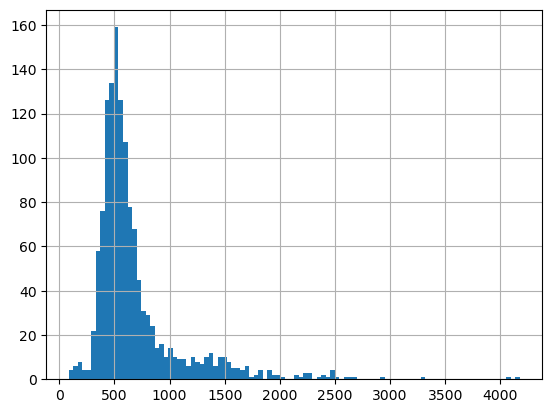

In [ ]:
print(apartments["price_per_m2"].describe())
apartments["price_per_m2"].hist(bins=100)



In [ ]:
apartments["full_cost"].quantile([0.5,0.6,0.7,0.8,0.9, 0.95, 0.99])

0.50     27500.00
0.60     29940.00
0.70     32600.00
0.80     37900.00
0.90     52864.60
0.95     71517.70
0.99    137488.08
Name: full_cost, dtype: float64

In [ ]:
#cap combination of empirical distribution - lower than 95 percentile and typical student affordability limits in Prague
apartments=apartments[apartments["full_cost"]<60000]

In [ ]:
apartments["price_per_m2"].quantile([0.5,0.6,0.7,0.8,0.9, 0.95, 0.99])

0.50     546.562500
0.60     585.319149
0.70     637.777778
0.80     719.230769
0.90     919.216216
0.95    1271.922481
0.99    1826.376000
Name: price_per_m2, dtype: float64

In [ ]:
#create price categories
bins = apartments["full_cost"].quantile([0.1, 0.5, 0.9]).values

apartments["price_group"] = pd.cut(
    apartments["full_cost"],
    bins=[0, bins[0], bins[1], bins[2], apartments["full_cost"].max()],
    labels=["very_cheap", "lower_student", "upper_student", "luxury"]
)



In [ ]:
apartments[apartments["price_group"]=="very_cheap"]

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,price_group
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,very_cheap
6,14990,0,45,DISP_2_KK,"Donská, Praha - Vršovice",Vršovice,14990,2+KK,333.111111,very_cheap
15,12990,0,30,DISP_1_KK,"Pelušková, Praha - Kyje",Kyje,12990,1+KK,433.000000,very_cheap
33,11500,2000,17,DISP_1_KK,"Na Cikánce, Praha - Radotín",Radotín,13500,1+KK,794.117647,very_cheap
37,13000,2500,77,DISP_3_1,"Bryksova, Praha - Černý Most",Černý Most,15500,3+1,201.298701,very_cheap
...,...,...,...,...,...,...,...,...,...,...
1326,14000,3000,24,DISP_1_KK,"Josefa Houdka, Praha - Lipence",Lipence,17000,1+KK,708.333333,very_cheap
1337,16490,0,39,DISP_1_KK,"Počernická, Praha - Malešice",Malešice,16490,1+KK,422.820513,very_cheap
1342,9000,3000,130,DISP_6_1,"Veltruská, Praha - Prosek",Prosek,12000,6+1,92.307692,very_cheap
1346,12000,3000,30,DISP_1_KK,"Chaloupky, Praha - Zadní Kopanina",Zadní Kopanina,15000,1+KK,500.000000,very_cheap


In [ ]:
apartments.sort_values("full_cost")

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,price_group
166,7500,0,86,DISP_4_KK,"Za Hotely, Horoměřice - Horoměřice, Středočesk...",Horoměřice,7500,4+KK,87.209302,very_cheap
618,7950,800,25,GARSONIERA,"Jana Želivského, Praha - Žižkov",Žižkov,8750,GARSONIERA,350.000000,very_cheap
846,10000,0,70,DISP_3_KK,"Janského, Praha - Stodůlky",Stodůlky,10000,3+KK,142.857143,very_cheap
1259,10400,1,85,DISP_5_1,"Vladivostocká, Praha - Vršovice",Vršovice,10401,5+1,122.364706,very_cheap
936,8000,2500,16,NaN,Praha - Chodov,Chodov,10500,unknown,656.250000,very_cheap
...,...,...,...,...,...,...,...,...,...,...
1063,50142,8848,40,NaN,"Dlážděná, Praha - Nové Město",Nové Město,58990,unknown,1474.750000,luxury
1168,45000,14000,98,DISP_3_KK,"U Sluncové, Praha - Karlín",Karlín,59000,3+KK,602.040816,luxury
701,50384,8891,49,NaN,"Rostovská, Praha - Vršovice",Vršovice,59275,unknown,1209.693878,luxury
19,50564,8923,30,NaN,"Washingtonova, Praha - Nové Město",Nové Město,59487,unknown,1982.900000,luxury


In [ ]:
distr=apartments.district.value_counts()
distr.index.tolist()
for d in distr.index.tolist():
    print(d)


Žižkov
Vysočany
Libeň
Vinohrady
Vršovice
Smíchov
Stodůlky
Holešovice
Nusle
Hloubětín
Nové Město
Strašnice
Karlín
Košíře
Chodov
Letňany
Bubeneč
Michle
Dejvice
Hlubočepy
Kobylisy
Krč
Modřany
Břevnov
Záběhlice
Vokovice
Malá Chuchle
Braník
Střížkov
Kyje
Kamýk
Prosek
Bohnice
Podolí
Horní Měcholupy
Hostivice
Řepy
Háje
Uhříněves
Ruzyně
Hostivař
Černý Most
Hrdlořezy
Staré Město
Zličín
Střešovice
Dolní Měcholupy
Motol
Čakovice
Horoměřice
Říčany
Troja
Malešice
Radlice
Liboc
Radotín
Zbraslav
Malá Strana
Kbely
Veleslavín
Jinonice
Lhotka
Štěrboholy
Horní Počernice
Hodkovičky
Suchdol
Čimice
Libuš
Vinoř
Újezd u Průhonic
Lipence
Třebonice
Dolní Chabry
Přezletice
Ďáblice
Hostavice
Kunratice
Libeř
Únětice
Dolní Počernice
Lahovice
Újezd nad Lesy
Nupaky
Lysolaje
Komořany
Běchovice
Královice
Šestajovice
Jeneč
Sedlec
Dubeč
Velká Chuchle
Křeslice
Vestec
Pitkovice
Benice
Přední Kopanina
Řeporyje
Veleň
Zadní Kopanina


In [ ]:
apartments["disposition_clean"]=apartments["disposition"].str.replace("DISP_","",regex=False).str.replace("_","+")

In [ ]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,price_group
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,lower_student
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,NaN,1194.725000,luxury
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,upper_student
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,very_cheap
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,upper_student
...,...,...,...,...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,luxury
1359,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,NaN,1213.935484,upper_student
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,upper_student
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,lower_student


In [ ]:
student_apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,price_group,zone
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,lower_student,outer_or_suburbs
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,upper_student,outer_or_suburbs
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,very_cheap,inner_city
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,upper_student,inner_city
5,28953,5109,24,NaN,"Zbraslavská, Praha - Malá Chuchle",Malá Chuchle,34062,NaN,1419.250000,upper_student,outer_or_suburbs
...,...,...,...,...,...,...,...,...,...,...,...
1357,21000,3000,41,DISP_2_KK,"Vorařská, Praha - Modřany",Modřany,24000,2+KK,585.365854,lower_student,outer_or_suburbs
1359,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,NaN,1213.935484,upper_student,inner_city
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,upper_student,inner_city
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,lower_student,inner_city


In [ ]:
center = [
    "Staré Město",
    "Nové Město",
    "Malá Strana"
]

inner_city = [
    "Vinohrady", "Žižkov", "Karlín", "Smíchov",
    "Holešovice", "Vršovice", "Nusle", "Dejvice",
    "Bubeneč", "Podolí", "Libeň", "Vysočany",
    "Košíře", "Břevnov", "Střešovice",
    "Vokovice", "Radlice", "Jinonice",
    "Hlubočepy", "Braník", "Michle",
    "Strašnice", "Kobylisy", "Prosek"
]

outer_city = [
    "Stodůlky", "Chodov", "Letňany", "Krč",
    "Modřany", "Záběhlice", "Kyje", "Kamýk",
    "Bohnice", "Hostivař", "Černý Most",
    "Řepy", "Háje", "Horní Měcholupy",
    "Malešice", "Troja", "Liboc", "Lhotka",
    "Štěrboholy", "Horní Počernice",
    "Čimice", "Libuš", "Kunratice",
    "Dolní Chabry", "Ďáblice", "Hostavice",
    "Dolní Počernice", "Komořany",
    "Běchovice", "Dubeč", "Řeporyje"
]

In [ ]:
def classify_zone(district):
    if district in center:
        return "center"
    elif district in inner_city:
        return "inner_city"
    else:
        return "outer_or_suburbs"

apartments["zone"] = apartments["district"].apply(classify_zone)

In [ ]:
student_apartments=apartments[
    apartments["price_group"].isin(["very_cheap","lower_student","upper_student"])
]

In [ ]:
district_stats = student_apartments.groupby(["zone", "disposition_clean"]).agg(
    avg_rent=("full_cost", "mean"),
    avg_m2_price=("price_per_m2", "mean"),
    count=("full_cost", "size")
).reset_index()

In [ ]:
district_stats

,zone,disposition_clean,avg_rent,avg_m2_price,count
0,center,1+1,22566.666667,687.672533,3
1,center,1+KK,25472.857143,976.291126,7
2,center,2+1,31237.500000,494.823965,8
3,center,2+KK,31115.714286,703.449520,7
4,center,3+1,35800.000000,421.176471,1
5,center,3+KK,36000.000000,500.000000,3
6,inner_city,1+1,21398.333333,545.719975,36
7,inner_city,1+KK,21562.980892,706.096441,157
8,inner_city,2+1,27749.073171,469.820999,82
9,inner_city,2+KK,27415.573276,546.596072,232


In [ ]:
apartment_monthly_cost=district_stats[district_stats["disposition_clean"].isin(["1+KK","2+KK","3+KK"])][["zone","disposition_clean","avg_rent"]]

In [ ]:
apartment_monthly_cost["people"]=(
    apartment_monthly_cost["disposition_clean"]
    .str[0]
    .astype(int)
)

In [ ]:
apartment_monthly_cost["avg_rent_per_person"]=(
    apartment_monthly_cost["avg_rent"]/apartment_monthly_cost["people"]
)

In [ ]:
apartment_monthly_cost

,zone,disposition_clean,avg_rent,people,avg_rent_per_person
1,center,1+KK,25472.857143,1,25472.857143
3,center,2+KK,31115.714286,2,15557.857143
5,center,3+KK,36000.000000,3,12000.000000
7,inner_city,1+KK,21562.980892,1,21562.980892
9,inner_city,2+KK,27415.573276,2,13707.786638
11,inner_city,3+KK,33512.333333,3,11170.777778
19,outer_or_suburbs,1+KK,20453.655172,1,20453.655172
21,outer_or_suburbs,2+KK,25619.248366,2,12809.624183
23,outer_or_suburbs,3+KK,30161.355556,3,10053.785185


[Text(0.5, 0, 'Disposition'), Text(0, 0.5, 'Monthly rent')]

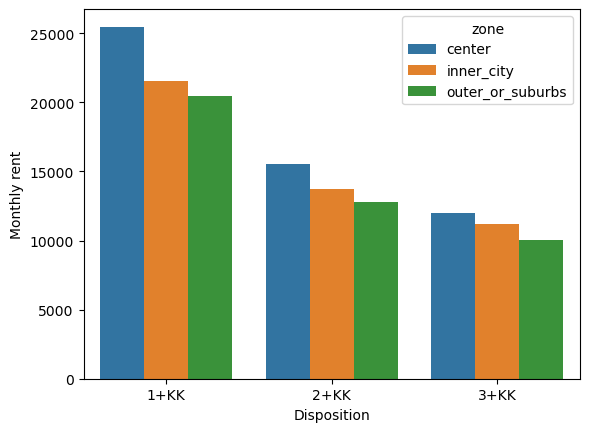

In [ ]:
sns.barplot(data=apartment_monthly_cost,x="disposition_clean",y="avg_rent_per_person",hue="zone").set(xlabel="Disposition", ylabel="Monthly rent")

In [ ]:
district_stats["avg_rent"].mean()

np.float64(25642.49327098918)

In [ ]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,price_group,zone
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,lower_student,outer_or_suburbs
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,NaN,1194.725000,luxury,inner_city
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,upper_student,outer_or_suburbs
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,very_cheap,inner_city
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,upper_student,inner_city
...,...,...,...,...,...,...,...,...,...,...,...
1358,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,luxury,inner_city
1359,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,NaN,1213.935484,upper_student,inner_city
1360,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,upper_student,inner_city
1361,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,lower_student,inner_city


In [ ]:
os.getcwd()

'c:\\Users\\chodu\\Desktop\\midterm2026\\project\\source_code'

In [ ]:
os.chdir("..")
apartments.to_csv(
    "data/clean/apartments_clean.csv",
    index=False
)

In [ ]:
district_stats.to_csv(
    "data/clean/district_stats.csv",
    index=False
)

In [ ]:
apartment_monthly_cost.to_csv(
    "data/clean/apartment_monthly_cost.csv",
    index=False
)

In [ ]:
os.getcwd()

'c:\\Users\\chodu\\Desktop\\midterm2026\\project'